# Generate Synthetic Risk Data for Training

Creates risk scores (0-1) based on weather, location, and historical factors.
Used to train XGBoost risk prediction model.

## Imports

In [1]:
import json
import random
from pathlib import Path
from typing import Dict, List
import numpy as np

## Configuration

Define feature ranges and weights for risk calculation.

In [2]:
# Feature ranges
FEATURE_RANGES = {
    "rainfall_mm": (0, 200),          # Daily rainfall in mm
    "temperature_c": (15, 45),         # Temperature in Celsius
    "humidity_pct": (30, 100),         # Humidity percentage
    "is_monsoon": (0, 1),              # Monsoon season flag
    "latitude": (8.0, 37.0),           # India latitude range
    "longitude": (68.0, 97.0),         # India longitude range
    "road_type_highway": (0, 1),       # One-hot: highway
    "road_type_urban": (0, 1),         # One-hot: urban road
    "road_type_rural": (0, 1),         # One-hot: rural road
    "traffic_density": (0, 1),         # Normalized traffic density
    "issue_count_30d": (0, 50),        # Issues in area (30 days)
    "is_hotspot": (0, 1),              # Known problem area
    "resolution_rate": (0, 1),         # Historical resolution rate
    "days_since_last_issue": (0, 365), # Days since last issue
    "population_density": (0, 1),      # Normalized population density
}

# Weights for risk calculation
RISK_WEIGHTS = {
    "rainfall_mm": 0.15,
    "is_monsoon": 0.10,
    "traffic_density": 0.12,
    "issue_count_30d": 0.15,
    "is_hotspot": 0.15,
    "resolution_rate": -0.10,  # Higher resolution = lower risk
    "days_since_last_issue": -0.08,  # Longer time = lower immediate risk
    "population_density": 0.10,
    "road_type_highway": 0.05,
    "humidity_pct": 0.05,
}

print("Feature ranges configured:", len(FEATURE_RANGES), "features")
print("Risk weights configured:", len(RISK_WEIGHTS), "weighted features")

Feature ranges configured: 15 features
Risk weights configured: 10 weighted features


## Risk Score Calculation Function

In [3]:
def calculate_risk_score(features: Dict[str, float]) -> float:
    """
    Calculate risk score from features using weighted formula.

    Args:
        features: Dictionary of feature values

    Returns:
        Risk score between 0 and 1
    """
    risk = 0.3  # Base risk

    for feature, weight in RISK_WEIGHTS.items():
        value = features.get(feature, 0)
        # Normalize value to 0-1 range
        min_val, max_val = FEATURE_RANGES.get(feature, (0, 1))
        normalized = (value - min_val) / (max_val - min_val) if max_val > min_val else value
        normalized = max(0, min(1, normalized))

        risk += weight * normalized

    # Add some random noise
    risk += random.uniform(-0.05, 0.05)

    # Clamp to 0-1
    return max(0.0, min(1.0, risk))

# Test the function
test_features = {
    "rainfall_mm": 100,
    "is_monsoon": 1,
    "traffic_density": 0.8,
    "issue_count_30d": 20,
    "is_hotspot": 1,
    "resolution_rate": 0.5,
    "days_since_last_issue": 10,
    "population_density": 0.7,
    "road_type_highway": 1,
    "humidity_pct": 80,
}
print(f"Test risk score: {calculate_risk_score(test_features):.4f}")

Test risk score: 0.8599


## Sample Generation Function

In [4]:
def generate_risk_sample() -> Dict:
    """
    Generate a single risk data sample.

    Returns:
        Dictionary with features and risk_score
    """
    # Generate base features with realistic distributions
    is_monsoon = random.choice([0, 0, 0, 1, 1])  # 40% monsoon

    # Rainfall depends on monsoon
    if is_monsoon:
        rainfall = random.uniform(20, 200)
    else:
        rainfall = random.uniform(0, 50)

    # Temperature inversely related to rainfall
    if rainfall > 50:
        temperature = random.uniform(20, 30)
    else:
        temperature = random.uniform(25, 42)

    # Humidity related to rainfall
    humidity = min(100, 40 + rainfall * 0.3 + random.uniform(0, 20))

    # Road type (one-hot encoded)
    road_types = ["highway", "urban", "rural"]
    road_type = random.choice(road_types)
    road_type_highway = 1 if road_type == "highway" else 0
    road_type_urban = 1 if road_type == "urban" else 0
    road_type_rural = 1 if road_type == "rural" else 0

    # Traffic density depends on road type
    if road_type == "highway":
        traffic = random.uniform(0.4, 1.0)
    elif road_type == "urban":
        traffic = random.uniform(0.3, 0.9)
    else:
        traffic = random.uniform(0.1, 0.5)

    # Historical factors
    is_hotspot = random.choice([0, 0, 0, 1])  # 25% hotspot

    if is_hotspot:
        issue_count = random.randint(10, 50)
        resolution_rate = random.uniform(0.3, 0.7)
        days_since = random.randint(0, 30)
    else:
        issue_count = random.randint(0, 15)
        resolution_rate = random.uniform(0.5, 1.0)
        days_since = random.randint(30, 365)

    # Location (India bounds with focus on urban centers)
    # Major cities roughly: Mumbai (19.0, 72.8), Delhi (28.6, 77.2), Bangalore (13.0, 77.6), Chennai (13.1, 80.3), Hyderabad (17.4, 78.5)
    city_centers = [
        (19.0, 72.8),  # Mumbai
        (28.6, 77.2),  # Delhi
        (13.0, 77.6),  # Bangalore
        (13.1, 80.3),  # Chennai
        (17.4, 78.5),  # Hyderabad
        (22.5, 88.3),  # Kolkata
        (23.0, 72.6),  # Ahmedabad
        (26.9, 75.8),  # Jaipur
    ]

    if random.random() < 0.7:  # 70% near cities
        center = random.choice(city_centers)
        latitude = center[0] + random.uniform(-0.5, 0.5)
        longitude = center[1] + random.uniform(-0.5, 0.5)
        population_density = random.uniform(0.5, 1.0)
    else:
        latitude = random.uniform(10, 32)
        longitude = random.uniform(72, 88)
        population_density = random.uniform(0.1, 0.5)

    features = {
        "rainfall_mm": round(rainfall, 1),
        "temperature_c": round(temperature, 1),
        "humidity_pct": round(humidity, 1),
        "is_monsoon": is_monsoon,
        "latitude": round(latitude, 4),
        "longitude": round(longitude, 4),
        "road_type_highway": road_type_highway,
        "road_type_urban": road_type_urban,
        "road_type_rural": road_type_rural,
        "traffic_density": round(traffic, 3),
        "issue_count_30d": issue_count,
        "is_hotspot": is_hotspot,
        "resolution_rate": round(resolution_rate, 3),
        "days_since_last_issue": days_since,
        "population_density": round(population_density, 3),
    }

    risk_score = calculate_risk_score(features)
    features["risk_score"] = round(risk_score, 4)

    return features

# Test sample generation
sample = generate_risk_sample()
print("Sample generated:")
for k, v in sample.items():
    print(f"  {k}: {v}")

Sample generated:
  rainfall_mm: 41.8
  temperature_c: 38.0
  humidity_pct: 61.5
  is_monsoon: 0
  latitude: 22.5698
  longitude: 72.5337
  road_type_highway: 0
  road_type_urban: 1
  road_type_rural: 0
  traffic_density: 0.888
  issue_count_30d: 27
  is_hotspot: 1
  resolution_rate: 0.395
  days_since_last_issue: 15
  population_density: 0.588
  risk_score: 0.6592


## Generate Training Dataset

In [5]:
def generate_training_data(num_samples: int = 10000) -> List[Dict]:
    """
    Generate risk training dataset.

    Args:
        num_samples: Number of samples to generate

    Returns:
        List of training samples
    """
    data = []
    random.seed(42)
    np.random.seed(42)

    for _ in range(num_samples):
        sample = generate_risk_sample()
        data.append(sample)

    return data

print("Generating risk training data...")
data = generate_training_data(10000)
print(f"Generated {len(data)} samples")

Generating risk training data...
Generated 10000 samples


## Analyze and Save Data

In [6]:
# Calculate statistics
risk_scores = [d["risk_score"] for d in data]

print(f"Risk score statistics:")
print(f"  Min: {min(risk_scores):.4f}")
print(f"  Max: {max(risk_scores):.4f}")
print(f"  Mean: {sum(risk_scores)/len(risk_scores):.4f}")

# Distribution of risk levels
low = sum(1 for r in risk_scores if r < 0.3)
medium = sum(1 for r in risk_scores if 0.3 <= r < 0.6)
high = sum(1 for r in risk_scores if 0.6 <= r < 0.8)
critical = sum(1 for r in risk_scores if r >= 0.8)

print(f"\nRisk level distribution:")
print(f"  Low (0-0.3): {low} ({low/len(data)*100:.1f}%)")
print(f"  Medium (0.3-0.6): {medium} ({medium/len(data)*100:.1f}%)")
print(f"  High (0.6-0.8): {high} ({high/len(data)*100:.1f}%)")
print(f"  Critical (0.8-1.0): {critical} ({critical/len(data)*100:.1f}%)")

Risk score statistics:
  Min: 0.1717
  Max: 1.0000
  Mean: 0.5290

Risk level distribution:
  Low (0-0.3): 473 (4.7%)
  Medium (0.3-0.6): 6217 (62.2%)
  High (0.6-0.8): 2554 (25.5%)
  Critical (0.8-1.0): 756 (7.6%)


In [7]:
# Save training data
output_dir = Path("../models")
output_dir.mkdir(exist_ok=True)

output_path = output_dir / "risk_training_data.json"
with open(output_path, "w") as f:
    json.dump(data, f, indent=2)

print(f"Saved to: {output_path}")

Saved to: ../models/risk_training_data.json


## Visualize Risk Distribution

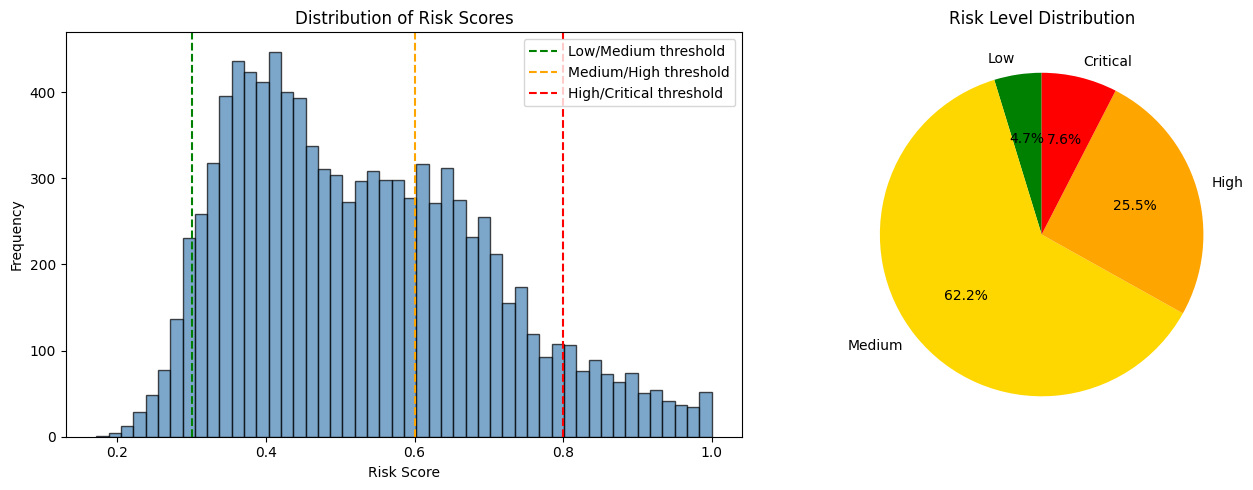

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score histogram
axes[0].hist(risk_scores, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Risk Scores')
axes[0].axvline(x=0.3, color='green', linestyle='--', label='Low/Medium threshold')
axes[0].axvline(x=0.6, color='orange', linestyle='--', label='Medium/High threshold')
axes[0].axvline(x=0.8, color='red', linestyle='--', label='High/Critical threshold')
axes[0].legend()

# Risk level pie chart
labels = ['Low', 'Medium', 'High', 'Critical']
sizes = [low, medium, high, critical]
colors = ['green', 'gold', 'orange', 'red']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Risk Level Distribution')

plt.tight_layout()
plt.show()